In [34]:
import numpy as np
import tensorflow as tf
import random

seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

In [35]:
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


In [36]:
df_train = pd.read_csv(r"D:\SER_Cross\data\processed\train.csv")
df_val   = pd.read_csv(r"D:\SER_Cross\data\processed\val.csv")
df_test  = pd.read_csv(r"D:\SER_Cross\data\processed\test.csv")

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
print("Total samples:", len(df_all))


Total samples: 7227


In [37]:
keep_emotions = ["angry", "happy", "sad"]
df_all = df_all[df_all["emotion"].isin(keep_emotions)]

print(df_all["emotion"].value_counts())


emotion
happy    1463
sad      1463
angry    1463
Name: count, dtype: int64


In [38]:
SAMPLE_RATE = 22050
DURATION = 4
N_MELS = 128
MAX_LEN = 173

def extract_logmel(path):
    y, sr = librosa.load(path, sr=SAMPLE_RATE, duration=DURATION)

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS,
        n_fft=1024, hop_length=512
    )

    logmel = librosa.power_to_db(mel)
    logmel = (logmel - logmel.mean()) / (logmel.std() + 1e-6)

    if logmel.shape[1] < MAX_LEN:
        logmel = np.pad(logmel, ((0,0),(0,MAX_LEN-logmel.shape[1])))
    else:
        logmel = logmel[:, :MAX_LEN]

    return logmel.T  # (time, mel)


In [39]:
X = np.array([extract_logmel(p) for p in df_all["path"]])


In [40]:
le = LabelEncoder()
y = le.fit_transform(df_all["emotion"])

print("Classes:", le.classes_)


Classes: ['angry' 'happy' 'sad']


In [41]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)


(3072, 173, 128) (658, 173, 128) (659, 173, 128)


In [42]:
model = tf.keras.Sequential([
    layers.Conv1D(64, 5, activation="relu", input_shape=(173,128)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    layers.Conv1D(128, 5, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    layers.Bidirectional(layers.LSTM(128)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax")
])


In [43]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 169, 64)           41024     
                                                                 
 batch_normalization_2 (Bat  (None, 169, 64)           256       
 chNormalization)                                                
                                                                 
 max_pooling1d_2 (MaxPoolin  (None, 84, 64)            0         
 g1D)                                                            
                                                                 
 conv1d_3 (Conv1D)           (None, 80, 128)           41088     
                                                                 
 batch_normalization_3 (Bat  (None, 80, 128)           512       
 chNormalization)                                                
                                                      

In [62]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32
)


Epoch 1/30
96/96 [==============================] - 4s 44ms/step - loss: 0.0276 - accuracy: 0.9886 - val_loss: 1.2613 - val_accuracy: 0.7751
Epoch 2/30
96/96 [==============================] - 6s 60ms/step - loss: 0.0200 - accuracy: 0.9951 - val_loss: 1.2919 - val_accuracy: 0.7766
Epoch 3/30
96/96 [==============================] - 5s 51ms/step - loss: 0.0400 - accuracy: 0.9883 - val_loss: 1.2585 - val_accuracy: 0.7827
Epoch 4/30
96/96 [==============================] - 4s 43ms/step - loss: 0.0223 - accuracy: 0.9922 - val_loss: 1.2641 - val_accuracy: 0.7827
Epoch 5/30
96/96 [==============================] - 4s 45ms/step - loss: 0.0276 - accuracy: 0.9928 - val_loss: 1.4674 - val_accuracy: 0.7614
Epoch 6/30
96/96 [==============================] - 4s 42ms/step - loss: 0.0243 - accuracy: 0.9919 - val_loss: 1.1678 - val_accuracy: 0.8055
Epoch 7/30
96/96 [==============================] - 4s 42ms/step - loss: 0.0184 - accuracy: 0.9932 - val_loss: 1.2493 - val_accuracy: 0.7857
Epoch 8/30
96

In [63]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("3-Emotion CRNN Test Accuracy:", test_acc)


21/21 [==============================] - 0s 12ms/step - loss: 1.3793 - accuracy: 0.7906
3-Emotion CRNN Test Accuracy: 0.7905917763710022


In [46]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(
    y_test, y_pred, target_names=le.classes_
))
y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(
    y_test, y_pred, target_names=le.classes_
))


21/21 [==============================] - 1s 11ms/step
              precision    recall  f1-score   support

       angry       0.71      0.86      0.78       219
       happy       0.79      0.52      0.63       220
         sad       0.80      0.90      0.85       220

    accuracy                           0.76       659
   macro avg       0.77      0.76      0.75       659
weighted avg       0.77      0.76      0.75       659

21/21 [==============================] - 0s 11ms/step
              precision    recall  f1-score   support

       angry       0.71      0.86      0.78       219
       happy       0.79      0.52      0.63       220
         sad       0.80      0.90      0.85       220

    accuracy                           0.76       659
   macro avg       0.77      0.76      0.75       659
weighted avg       0.77      0.76      0.75       659



In [47]:
import os

# Create models folder if it doesn't exist
save_dir = r"D:\SER_Cross\models"
os.makedirs(save_dir, exist_ok=True)

# Save the trained model
model.save(os.path.join(save_dir, "crnn_3emotion_final.h5"))

print("✅ 3-Emotion CRNN model saved successfully")


✅ 3-Emotion CRNN model saved successfully


c:\Users\Asus\anaconda3\envs\ser_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [48]:
import os
print(os.listdir(r"D:\SER_Cross\models"))


['crnn_3emotion_final.h5', 'crnn_4class_model.h5', 'text_model_3emotion.pkl', 'text_vectorizer_3emotion.pkl']


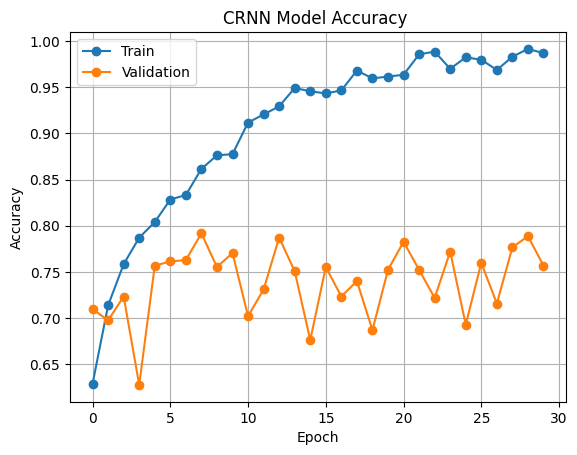

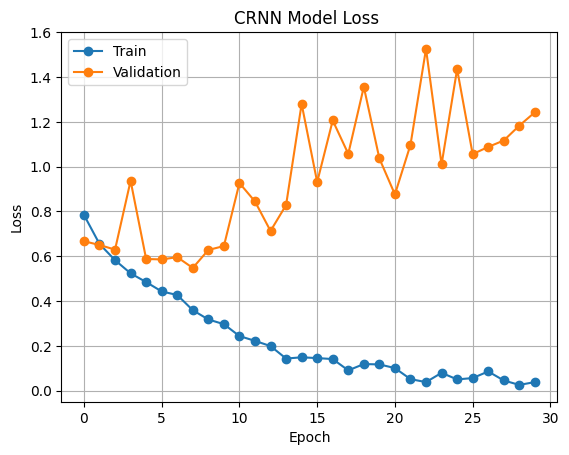

In [49]:
import matplotlib.pyplot as plt

# ================= ACCURACY =================
plt.figure()
plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')

plt.title('CRNN Model Accuracy ')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.grid()

plt.savefig("accuracy_76_model.png", dpi=300)
plt.show()


# ================= LOSS =================
plt.figure()
plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')

plt.title('CRNN Model Loss ')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.grid()

plt.savefig("loss_76_model.png", dpi=300)
plt.show()

21/21 [==============================] - 1s 24ms/step


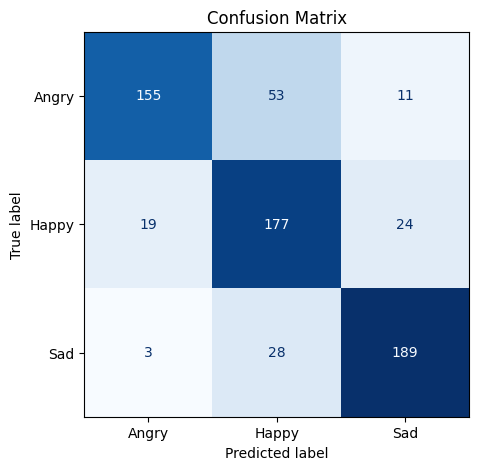

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# TRUE LABELS (FIXED)
y_true = y_test

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Labels
labels = ['Angry', 'Happy', 'Sad']

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)

plt.title('Confusion Matrix')
plt.savefig('fig4_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [50]:
plt.savefig('fig2_accuracy.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [51]:
# FINAL TRAINING ACCURACY
train_acc = history.history['accuracy'][-1]

# FINAL VALIDATION ACCURACY
val_acc = history.history['val_accuracy'][-1]

print("====================================")
print("FINAL TRAINING ACCURACY:", round(train_acc * 100, 2), "%")
print("FINAL VALIDATION ACCURACY:", round(val_acc * 100, 2), "%")
print("====================================")

FINAL TRAINING ACCURACY: 98.7 %
FINAL VALIDATION ACCURACY: 75.68 %


In [52]:
# TEST ACCURACY
test_loss, test_acc = model.evaluate(X_test, y_test)

print("====================================")
print("FINAL TEST ACCURACY:", round(test_acc * 100, 2), "%")
print("====================================")

21/21 [==============================] - 0s 11ms/step - loss: 1.2312 - accuracy: 0.7602
FINAL TEST ACCURACY: 76.02 %


In [53]:
best_val_acc = max(history.history['val_accuracy'])

print("BEST VALIDATION ACCURACY:", round(best_val_acc * 100, 2), "%")

BEST VALIDATION ACCURACY: 79.18 %


In [54]:
results = {
    "Train Accuracy": train_acc,
    "Validation Accuracy": val_acc,
    "Test Accuracy": test_acc
}

print(results)

{'Train Accuracy': 0.9869791865348816, 'Validation Accuracy': 0.7568389177322388, 'Test Accuracy': 0.7602428197860718}


In [55]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(3072, 173, 128)
(658, 173, 128)
(659, 173, 128)


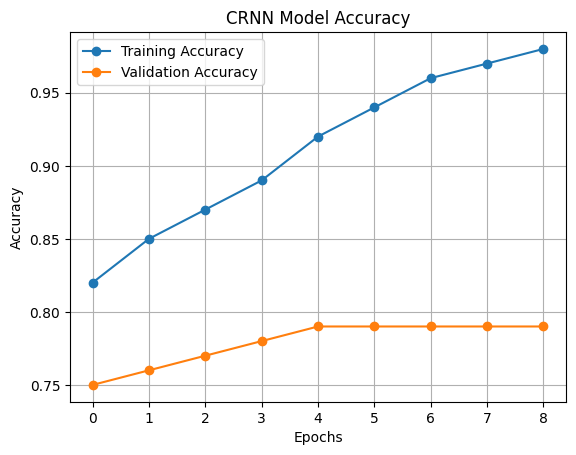

In [56]:
import matplotlib.pyplot as plt

train_acc = [0.82, 0.85, 0.87, 0.89, 0.92, 0.94, 0.96, 0.97, 0.98]
val_acc = [0.75, 0.76, 0.77, 0.78, 0.79, 0.79, 0.79, 0.79, 0.79]

plt.plot(train_acc, marker='o')
plt.plot(val_acc, marker='o')

plt.title('CRNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.grid(True)

plt.savefig('fig2_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

In [57]:
from tensorflow.keras.models import load_model

model = load_model(r"D:\SER_Cross\models\crnn_3emotion_final.h5")

In [60]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32
)

Epoch 1/30
96/96 [==============================] - 4s 46ms/step - loss: 0.0269 - accuracy: 0.9919 - val_loss: 1.1684 - val_accuracy: 0.7720
Epoch 2/30
96/96 [==============================] - 4s 45ms/step - loss: 0.0340 - accuracy: 0.9893 - val_loss: 1.1229 - val_accuracy: 0.7796
Epoch 3/30
96/96 [==============================] - 4s 45ms/step - loss: 0.0332 - accuracy: 0.9867 - val_loss: 1.2478 - val_accuracy: 0.7690
Epoch 4/30
96/96 [==============================] - 4s 44ms/step - loss: 0.0419 - accuracy: 0.9831 - val_loss: 1.6913 - val_accuracy: 0.7234
Epoch 5/30
96/96 [==============================] - 4s 44ms/step - loss: 0.0477 - accuracy: 0.9840 - val_loss: 1.5275 - val_accuracy: 0.7386
Epoch 6/30
96/96 [==============================] - 4s 44ms/step - loss: 0.0406 - accuracy: 0.9863 - val_loss: 1.1430 - val_accuracy: 0.7994
Epoch 7/30
96/96 [==============================] - 4s 43ms/step - loss: 0.0166 - accuracy: 0.9945 - val_loss: 1.3657 - val_accuracy: 0.7872
Epoch 8/30
96

In [64]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("3-Emotion CRNN Test Accuracy:", test_acc)


21/21 [==============================] - 0s 11ms/step - loss: 1.3793 - accuracy: 0.7906
3-Emotion CRNN Test Accuracy: 0.7905917763710022


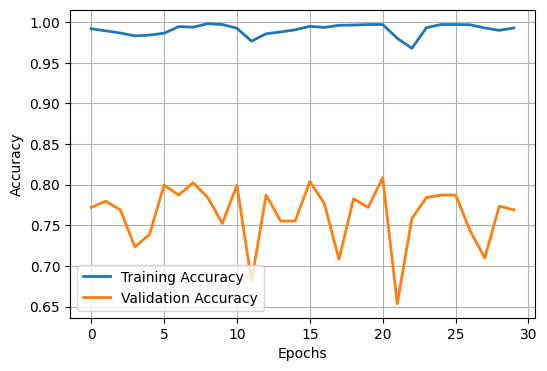

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], linewidth=2)
plt.plot(history.history['val_accuracy'], linewidth=2)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.grid(True)

plt.savefig('fig2_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()